### Step 1: Data Collection

In [16]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
# Load Dataset
import pandas as pd


customer_data = pd.read_csv("D:\Gopal_ubuntu1\BigData_datasets\customer_data.csv")

In [18]:
# Display first 5 records.
customer_data.head()

,CustomerID,Age,Gender,Location,TotalPurchases,TotalAmountSpent,LastPurchaseDate
0,1,68,Female,Houston,24,595.11,2023-01-01
1,2,35,Male,Phoenix,29,2901.57,2023-01-08
2,3,60,Male,Phoenix,19,4109.95,2023-01-15
3,4,63,Female,Chicago,27,2324.75,2023-01-22
4,5,42,Male,Los Angeles,15,1122.67,2023-01-29


In [19]:
#Check Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        100 non-null    int64         
 1   Age               100 non-null    int64         
 2   Gender            100 non-null    object        
 3   Location          100 non-null    object        
 4   TotalPurchases    100 non-null    int64         
 5   TotalAmountSpent  100 non-null    float64       
 6   LastPurchaseDate  100 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(3), object(2)
memory usage: 5.6+ KB


### Step 2: Data Preprocessing

In [ ]:
# Check Missing Values
df.isnull().sum()

# df.fillna(0,inplace=True)
# df.dropna(inplace=True)

CustomerID          0
Age                 0
Gender              0
Location            0
TotalPurchases      0
TotalAmountSpent    0
LastPurchaseDate    0
dtype: int64

In [14]:
# Convert Date Column
df['LastPurchaseDate']=pd.to_datetime(df['LastPurchaseDate'])

In [15]:
# Statistical Summary
df.describe()

,CustomerID,Age,TotalPurchases,TotalAmountSpent,LastPurchaseDate
count,100.000000,100.000000,100.000000,100.000000,100
mean,50.500000,45.090000,16.620000,2494.188400,2023-12-13 12:00:00
min,1.000000,18.000000,1.000000,57.640000,2023-01-01 00:00:00
25%,25.750000,31.000000,9.750000,1112.405000,2023-06-23 06:00:00
50%,50.500000,45.500000,15.000000,2626.165000,2023-12-13 12:00:00
75%,75.250000,60.000000,26.000000,3812.867500,2024-06-03 18:00:00
max,100.000000,70.000000,30.000000,4966.480000,2024-11-24 00:00:00
std,29.011492,15.814643,9.032802,1471.248513,NaN


In [22]:
df['Gender'].value_counts()

Gender
Female    50
Male      50
Name: count, dtype: int64

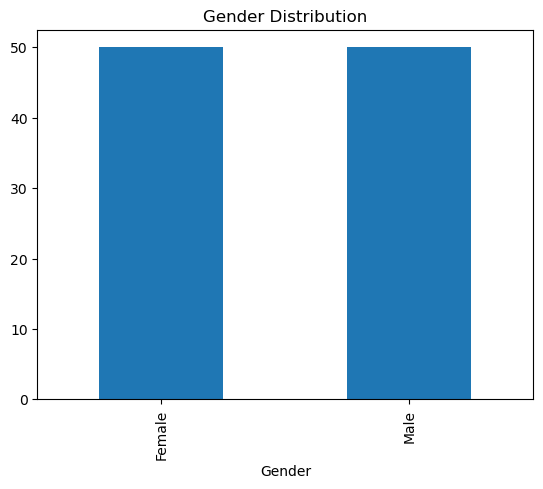

In [21]:
# Gender Distribution

df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

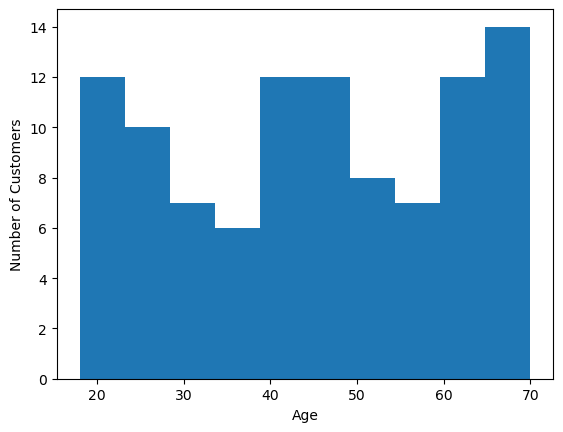

In [23]:
# Age Distribution
plt.hist(df['Age'])
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [24]:
# Location Distribution
df['Location'].value_counts()

Location
Houston        32
Phoenix        21
Chicago        18
New York       15
Los Angeles    14
Name: count, dtype: int64

### Step 3: Data Analysis

### Average Purchase Value by Age and Gender

In [25]:
# Average Purchase by Gender
df.groupby('Gender')['TotalAmountSpent'].mean()

Gender
Female    2263.2020
Male      2725.1748
Name: TotalAmountSpent, dtype: float64

In [30]:
# Total Purchase Amount by Location

df.groupby('Location')['TotalAmountSpent'].sum()

Location
Chicago        46500.07
Houston        80502.02
Los Angeles    31043.26
New York       31409.18
Phoenix        59964.31
Name: TotalAmountSpent, dtype: float64

In [26]:
# Create Age Groups
bins=[0,25,35,45,60,100]

labels=['18-25','26-35','36-45','46-60','60+']

df['AgeGroup']=pd.cut(df['Age'],
                      bins=bins,
                      labels=labels)

In [27]:
# Average Spending by Age Group
df.groupby('AgeGroup')['TotalAmountSpent'].mean()

AgeGroup
18-25    2470.107143
26-35    2702.492632
36-45    2282.241765
46-60    2563.377586
60+      2397.805714
Name: TotalAmountSpent, dtype: float64

### Customer Loyalty

In [ ]:
# Find Top Customers
df.sort_values(by='TotalAmountSpent',
ascending=False).head(10)

In [28]:
# Find Loyal Customers
df.sort_values(by='TotalPurchases',
ascending=False).head(10)

,CustomerID,Age,Gender,Location,TotalPurchases,TotalAmountSpent,LastPurchaseDate,AgeGroup
17,18,42,Male,Houston,30,3788.89,2023-04-30,36-45
84,85,24,Female,Chicago,30,791.92,2024-08-11,18-25
10,11,21,Female,Los Angeles,30,1621.33,2023-03-12,18-25
78,79,43,Male,Chicago,30,4766.31,2024-06-30,36-45
34,35,43,Female,Phoenix,29,2115.42,2023-08-27,36-45
45,46,32,Male,Chicago,29,99.45,2023-11-12,26-35
1,2,35,Male,Phoenix,29,2901.57,2023-01-08,26-35
93,94,62,Female,Houston,29,230.64,2024-10-13,60+
51,52,26,Female,Houston,29,871.03,2023-12-24,26-35
67,68,64,Male,Phoenix,29,3168.03,2024-04-14,60+


### Churn Rate

In [35]:
# Inactive Customers
today=pd.Timestamp('2024-01-01')

df['Days']=today-df['LastPurchaseDate']

df['Days']=df['Days'].dt.days

In [34]:
# More than 180 days
churn=df[df['Days']>180]
len(churn)   #Customer Count


27

### Insights and Business Recommendation

Insight 1

Male customers spend more than female customers.

Recommendation

Promote premium products to male customers.

Insight 2

Customers aged 26-35 spend the highest amount.

Recommendation

Target this age group with advertisements.

Insight 3

Houston has the highest revenue.

Recommendation

Increase marketing campaigns in Houston.

Insight 4

Customers with high purchase frequency are loyal customers.

Recommendation

Provide reward points and membership.

Insight 5

Top spending customers generate most of the revenue.

Recommendation

Provide personalized discounts and VIP membership.